In [1]:
import alfabet
alfabet.__version__ # Must return: '0.4.1'

'0.4.1'

In [2]:
import copy

from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

from alfabet import model, drawing, fragment


from IPython.display import SVG
from IPython.core.display import HTML

from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.molSize = (300, 300)   # Change image size
IPythonConsole.ipython_useSVG = True  # Change output to SVG
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.drawOptions.minFontSize = 18
IPythonConsole.drawOptions.prepareMolsBeforeDrawing = True

In [3]:
def draw_bde(smiles, bond_index_input, bond_type, bde_pred, figwidth=200):
    mol = Chem.MolFromSmiles(smiles)
    bond_index = copy.copy(bond_index_input)
    bond_index = int(bond_index)

    if mol.GetNumAtoms() > 20:
        figwidth = 300
    if mol.GetNumAtoms() > 40:
        figwidth = 400

    if bond_index >= mol.GetNumBonds():
        molH = Chem.AddHs(mol)
        if bond_index >= molH.GetNumBonds():
            raise RuntimeError(
                f"Fewer than {bond_index} bonds in {smiles}: "
                f"{molH.GetNumBonds()} total bonds"
            )
        bond = molH.GetBondWithIdx(bond_index)

        start_atom = mol.GetAtomWithIdx(bond.GetBeginAtomIdx())
        mol = Chem.AddHs(mol, onlyOnAtoms=[start_atom.GetIdx()])
        bond_index = mol.GetNumBonds() - 1

    if not mol.GetNumConformers():
        rdDepictor.Compute2DCoords(mol)

    drawer = rdMolDraw2D.MolDraw2DSVG(figwidth, figwidth)
    drawer.drawOptions().fixedBondLength = 30
    drawer.drawOptions().highlightBondWidthMultiplier = 20

    drawer.DrawMolecule(
        mol,
        highlightAtoms=[],
        highlightBonds=[bond_index],
        legend=(f'Idx: {bond_index_input}, BDE: {bde_pred:.2f}'),
    )

    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def generate_structure(df, subImgSize=(300,300), molsPerRow=3):

    nRows = df.shape[0] // molsPerRow
    if df.shape[0] % molsPerRow:
        nRows += 1
    if nRows == 1:
        molsPerRow = df.shape[0]
    fullSize = (molsPerRow * subImgSize[0], nRows * subImgSize[1])

    header = """<svg version='1.1' baseProfile='full'
                xmlns='http://www.w3.org/2000/svg'
                        xmlns:rdkit='http://www.rdkit.org/xml'
                        xmlns:xlink='http://www.w3.org/1999/xlink'
                    xml:space='preserve'
    width='{0}px' height='{1}px' viewBox='0 0 {0} {1}'>
    <!-- END OF HEADER -->""".format(fullSize[0],fullSize[1])

    spacer = '<g transform="translate({0},{1})">\n{2}</g>'

    # Draw molecule    
    cwidth = 0
    cheight = 0
    drawed_mols = []
    i = 0
    for idx, row in df.iterrows():
        smiles = row.molecule
        bond_index = row.bond_index
        bond_type = row.bond_type
        bde_pred = row.bde_pred

        res = draw_bde(smiles, bond_index, bond_type, bde_pred, figwidth=300)
        res = res.split("\n")
        end_of_header = res.index("<!-- END OF HEADER -->") + 1 
        res = "\n".join(res[end_of_header:-2])
        
        res = "".join(spacer.format(int(cwidth*subImgSize[0]), int(cheight*subImgSize[1]), res))
        drawed_mols.append(res)
        
        if int(i+1) % molsPerRow == 0 and i != 0:
            cheight += 1
            cwidth = 0
        elif molsPerRow == 1:
            cheight += 1
            cwidth = 0
        else:
            cwidth += 1
        i += 1

    svg = header + "\n" + "\n".join(drawed_mols) + "\n</svg>"

    return svg


In [4]:
random_pred = model.predict(['CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2ccc3c(c2)OCO3)C1=O']).sort_values(by='bde_pred')

2024-10-25 13:06:41.480619: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


In [5]:
random_pred

,molecule,bond_index,bond_type,fragment1,fragment2,is_valid_stereo,bde_pred,bdfe_pred,is_valid,bde,bdfe,set
11,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,47,C-H,[H],[H]c1c([H])c([C]2c3c(c4c([H])c([H])c([H])c([H]...,True,75.006073,67.552368,True,NaN,NaN,NaN
4,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,39,C-H,[H],[H]c1c([H])c([C@]2([H])c3c(c4c([H])c([H])c([H]...,True,78.200249,69.821358,True,NaN,NaN,NaN
1,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,17,C-C,[H][C]1c2c(c3c([H])c([H])c([H])c([H])c3n2[H])C...,[H]c1[c]c([H])c2c(c1[H])OC([H])([H])O2,True,81.207977,67.284996,True,NaN,NaN,NaN
3,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,37,C-H,[H],[H][C]1C(=O)N2[C@]([H])(c3c([H])c([H])c4c(c3[H...,True,82.415520,74.398926,True,NaN,NaN,NaN
5,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,40,C-H,[H],[H][C]1c2c(n([H])c3c([H])c([H])c([H])c([H])c23...,True,87.774673,79.341705,True,NaN,NaN,NaN
15,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,51,C-H,[H],[H][C]1Oc2c([H])c([H])c([C@]3([H])c4c(c5c([H])...,True,91.089233,82.810593,True,NaN,NaN,NaN
6,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,42,H-N,[H],[H]c1c([H])c([H])c2c(c1[H])[N]C1=C2C([H])([H])...,True,92.415329,84.071915,True,NaN,NaN,NaN
2,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,34,C-H,[H],[H][C]([H])N1C(=O)[C@]2([H])N(C(=O)C1([H])[H])...,True,93.097984,85.142754,True,NaN,NaN,NaN
0,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,0,C-N,[H][C]([H])[H],[H]c1c([H])c([C@]2([H])c3c(c4c([H])c([H])c([H]...,True,95.923378,82.862259,True,NaN,NaN,NaN
8,CN1CC(=O)N2[C@H](Cc3c([nH]c4ccccc34)[C@H]2c2cc...,44,C-H,[H],[H]c1[c]c([H])c2c(c1[H])c1c(n2[H])[C@@]([H])(c...,True,111.232414,102.771667,True,NaN,NaN,NaN


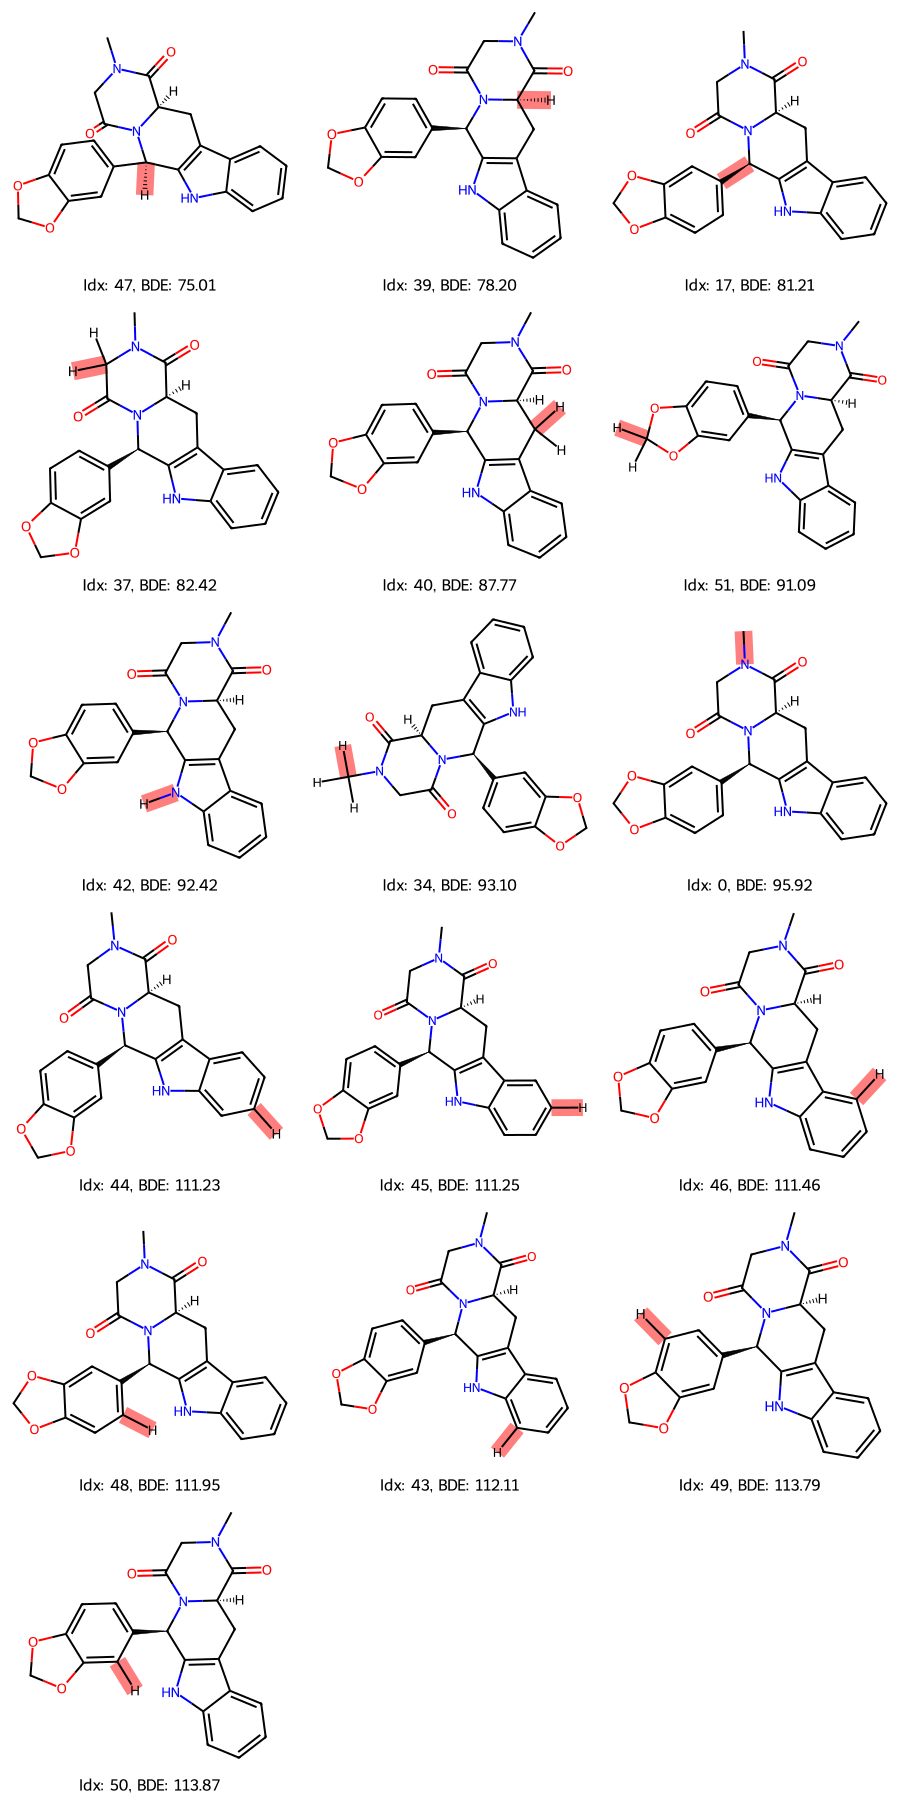

In [6]:
SVG(generate_structure(random_pred))

In [7]:
cmpds_in_paper = ['C(N(C)C)C(C)=O', 'CN(CC(C1C=CC=CC=1)=O)C', 'CC(OO)(C)C', 'C/C=C/CC', 'C/C=C\CC', 'C1C=CC=CC=1C(C)C', 'CCC=C', 'CCOO', 'C/C=C\C', 'CC(C)OO', 'C/C=C/C', 'N(C)(C)C', 'C=COO', 'C(C1C=CC=CC=1)COO', 'N(C)C', 'OO', 'OOC', 'OOCC#N', 'N1CCCC1', 'OOCCl', 'NCCO', 'CC(=O)N(C)C', 'OOC(C)Cl', 'N#CC(C)C', 'C1CCCCN1', 'O1CCCC1', 'O(C)C', 'CC(NC(C)C)=O', 'NCCC', 'NC', 'SC', 'C(O)(C)=O', 'CC(C)C', 'CO', 'CCCl', 'CCCCl', 'CCCCl', 'CCC', 'CCCCC', 'CCCl', 'CC', 'CCCC', 'CCC', 'CCl', 'C1C=CC=CN=1']
cmpds_in_paper2 = ['C12C=CC=CC=1N(CCCN(C)C)C1C=CC=CC=1CC2', 'COc1ccc(c(c1)C(C(N)C)O)OC', 'CN[C@H]1CC[C@H](C2=CC=CC=C12)C3=CC(=C(C=C3)Cl)Cl', 'CC1=C(C(C(=C(N1)C)C(=O)OC)C2=CC=CC=C2[N+](=O)[O-])C(=O)OC', 'CC(=O)Nc1ccc(cc1)O', 'CC(=O)Oc1ccccc1C(=O)O', 'CN1C2=C(C(C3=CC=CC=C3)=NCC1=O)C=C(Cl)C=C2', 'CN1CC[C@@]23CCCC[C@@H]2[C@@H]1CC4=C3C=C(C=C4)OC', 'COc1ccc(-n2nc(C(=O)N(C)C)c3c4ccc(Cl)cc4n(C)c3c2=O)cn1', 'CCOC(=O)COC1=CC2=C(CC[C@@H](C2)NC[C@@H](C3=CC(=CC=C3)Cl)O)C=C1']
print(len(cmpds_in_paper))
print(len(cmpds_in_paper2))
cmpds_in_paper = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in cmpds_in_paper]
cmpds_in_paper2 = [Chem.MolToSmiles(Chem.MolFromSmiles(smi)) for smi in cmpds_in_paper2]

45
10


In [8]:
smi = cmpds_in_paper[0]
# smi = cmpds_in_paper2[0]

random_pred = model.predict([smi]).sort_values(by='bde_pred')
random_pred = random_pred[random_pred.bond_type.str.contains('H')] # only X-H

In [9]:
random_pred

,molecule,bond_index,bond_type,fragment1,fragment2,is_valid_stereo,bde_pred,bdfe_pred,is_valid,bde,bdfe,set
5,CC(=O)CN(C)C,9,C-H,[H],[H][C](C(=O)C([H])([H])[H])N(C([H])([H])[H])C(...,True,81.341064,72.184464,True,81.161387,72.201186,train
6,CC(=O)CN(C)C,11,C-H,[H],[H][C]([H])N(C([H])([H])[H])C([H])([H])C(=O)C(...,True,92.179237,83.269577,True,92.172287,83.160003,train
4,CC(=O)CN(C)C,6,C-H,[H],[H][C]([H])C(=O)C([H])([H])N(C([H])([H])[H])C(...,True,94.055733,86.114967,True,94.078659,85.998853,train


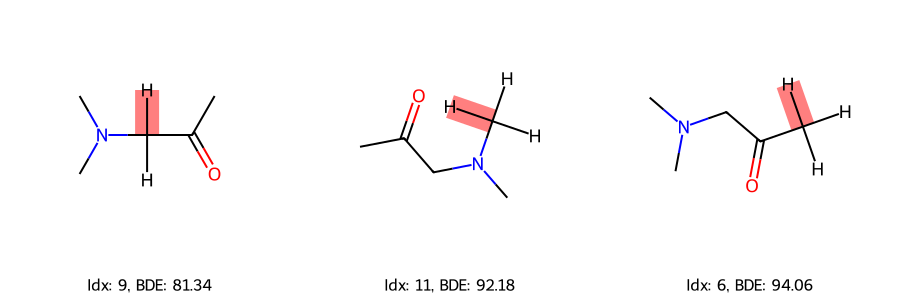

In [10]:
SVG(generate_structure(random_pred))

In [9]:
import os
import sys
import numpy as np
import pandas as pd

import hashlib
from rdkit import Chem
from alfabet import model as bde_model

def get_atom_index(smiles, bond_index):
    rdkit_mol = Chem.MolFromSmiles(smiles)
    rdkit_molHs = Chem.AddHs(rdkit_mol)
    bond = rdkit_molHs.GetBondWithIdx(bond_index)
    if bond.GetBeginAtom().GetAtomicNum() == 1: # "1" is the atomic number and corresponds to hydrogen
        atom_site = bond.GetEndAtomIdx()
    elif bond.GetEndAtom().GetAtomicNum() == 1: # "1" is the atomic number and corresponds to hydrogen
        atom_site = bond.GetBeginAtomIdx()
    else:
        print(f'WARNING! Atom index cannot be found!')
    return atom_site


# Run ALFABET predictions
smiles = 'CCOC(=O)c1cc(Cl)n2nc(-c3ccc(Br)cc3F)cc2n1' # from Fig.3a in https://doi.org/10.1002/anie.202411296
smiles = 'c1cnc2ccoc2c1'
smiles = Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True) # canonicalize input smiles
name = hashlib.md5(smiles.encode()).hexdigest() # SMILES MUST BE CANONICALIZED

df_bde = bde_model.predict([smiles], drop_duplicates=False).sort_values(by='bde_pred')
df_bde = df_bde[df_bde.bond_type == 'C-H'] # only C-H
df_bde['Atom ID'] = df_bde.apply(lambda row: get_atom_index(smiles, row['bond_index']), axis=1) if df_bde.shape[0] else []
# df_bde = df_bde[['Atom ID', 'bde_pred']].rename(columns={'bde_pred': 'BDE Value [kcal/mol]'})
df_bde = df_bde.rename(columns={'bde_pred': 'BDE Value [kcal/mol]'})
df_bde['Reactant'] = df_bde['Atom ID'].apply(lambda site: f'<a href="#" class="show-structure-link" data-atom-id="{site}" sdf_path="{name}/{name}.sdf">Show</a>')
df_bde

,molecule,bond_index,bond_type,fragment1,fragment2,is_valid_stereo,BDE Value [kcal/mol],bdfe_pred,is_valid,bde,bdfe,set,Atom ID,Reactant
1,c1cnc2ccoc2c1,11,C-H,[H],[H]c1[c]nc2c([H])c([H])oc2c1[H],True,106.664680,98.159714,True,106.769401,98.248457,test,1,"<a href=""#"" class=""show-structure-link"" data-a..."
0,c1cnc2ccoc2c1,10,C-H,[H],[H]c1[c]c([H])c2oc([H])c([H])c2n1,True,112.705261,104.251221,True,112.570722,104.053542,test,0,"<a href=""#"" class=""show-structure-link"" data-a..."
4,c1cnc2ccoc2c1,14,C-H,[H],[H]c1[c]c2oc([H])c([H])c2nc1[H],True,112.828682,104.365990,True,112.657946,104.149551,test,8,"<a href=""#"" class=""show-structure-link"" data-a..."
3,c1cnc2ccoc2c1,13,C-H,[H],[H]c1nc2c([H])[c]oc2c([H])c1[H],True,117.379951,108.898026,True,117.220564,108.709032,test,5,"<a href=""#"" class=""show-structure-link"" data-a..."
2,c1cnc2ccoc2c1,12,C-H,[H],[H]c1[c]c2nc([H])c([H])c([H])c2o1,True,119.649765,111.106598,True,119.433160,110.935434,test,4,"<a href=""#"" class=""show-structure-link"" data-a..."


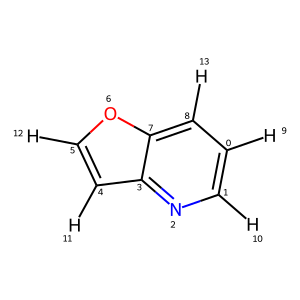

In [34]:
Chem.AddHs(Chem.MolFromSmiles(smiles))

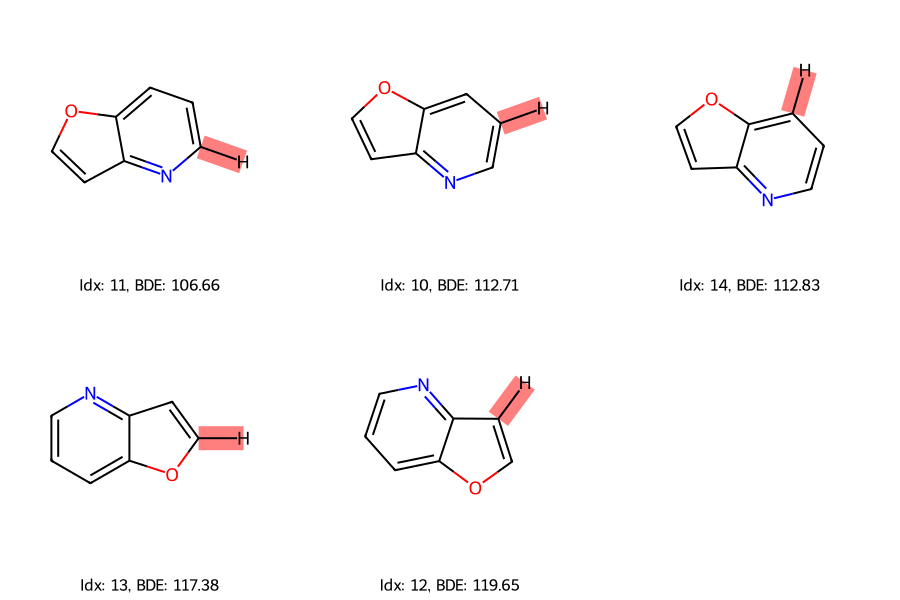

In [37]:
df_bde = bde_model.predict([smiles], drop_duplicates=False).sort_values(by='bde_pred')
df_bde = df_bde[df_bde.bond_type == 'C-H'] # only C-H
SVG(generate_structure(df_bde))